In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from wordcloud import WordCloud 


In [4]:
df = pd.read_parquet('../data/processed/dblp_2018.parquet')
df.head()

,type,year,title,authors,source
0,incollection,2021,Blockchains and Distributed Ledgers Uncovered:...,"Eder J. Scheid, Bruno Bastos Rodrigues, Christ...",IFIP's Exciting First 60+ Years
1,incollection,2024,A Common Ground for Developing a Global Consci...,Don Gotterbarn,IFIP TC9 50th Anniversary Anthology
2,incollection,2021,An IFIP WG5.8 State-of-the-Art View on Methods...,"Georg Weichhart, Yves Ducq, Guy Doumeingts",IFIP's Exciting First 60+ Years
3,incollection,2021,IFIP Code of Ethics.,David Kreps,IFIP's Exciting First 60+ Years
4,incollection,2024,Introduction - Legacies of the Formation of IF...,"Christopher Leslie, David Kreps",IFIP TC9 50th Anniversary Anthology


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3912885 entries, 0 to 3912884
Data columns (total 5 columns):
 #   Column   Dtype
---  ------   -----
 0   type     str  
 1   year     int64
 2   title    str  
 3   authors  str  
 4   source   str  
dtypes: int64(1), str(4)
memory usage: 783.1 MB


In [6]:
df.isna().mean().sort_values(ascending=False)

source     0.000864
type       0.000000
year       0.000000
title      0.000000
authors    0.000000
dtype: float64

In [7]:
df.shape

(3912885, 5)

In [8]:
df = df.dropna(subset=['source'])

In [9]:
df.shape

(3909503, 5)

In [10]:
df['author_count'] = (df['authors'].str.split(',').str.len()).astype(int)

In [11]:
df.head()

,type,year,title,authors,source,author_count
0,incollection,2021,Blockchains and Distributed Ledgers Uncovered:...,"Eder J. Scheid, Bruno Bastos Rodrigues, Christ...",IFIP's Exciting First 60+ Years,6
1,incollection,2024,A Common Ground for Developing a Global Consci...,Don Gotterbarn,IFIP TC9 50th Anniversary Anthology,1
2,incollection,2021,An IFIP WG5.8 State-of-the-Art View on Methods...,"Georg Weichhart, Yves Ducq, Guy Doumeingts",IFIP's Exciting First 60+ Years,3
3,incollection,2021,IFIP Code of Ethics.,David Kreps,IFIP's Exciting First 60+ Years,1
4,incollection,2024,Introduction - Legacies of the Formation of IF...,"Christopher Leslie, David Kreps",IFIP TC9 50th Anniversary Anthology,2


In [12]:
df['title_length'] = (df['title'].str.len()).astype(int)

In [13]:
df.head()

,type,year,title,authors,source,author_count,title_length
0,incollection,2021,Blockchains and Distributed Ledgers Uncovered:...,"Eder J. Scheid, Bruno Bastos Rodrigues, Christ...",IFIP's Exciting First 60+ Years,6,93
1,incollection,2024,A Common Ground for Developing a Global Consci...,Don Gotterbarn,IFIP TC9 50th Anniversary Anthology,1,103
2,incollection,2021,An IFIP WG5.8 State-of-the-Art View on Methods...,"Georg Weichhart, Yves Ducq, Guy Doumeingts",IFIP's Exciting First 60+ Years,3,99
3,incollection,2021,IFIP Code of Ethics.,David Kreps,IFIP's Exciting First 60+ Years,1,20
4,incollection,2024,Introduction - Legacies of the Formation of IF...,"Christopher Leslie, David Kreps",IFIP TC9 50th Anniversary Anthology,2,71


In [14]:
df.describe()

,year,author_count,title_length
count,3.909503e+06,3.909503e+06,3.909503e+06
mean,2.021928e+03,4.059771e+00,8.573246e+01
std,2.335132e+00,2.630483e+00,2.771472e+01
min,2.018000e+03,1.000000e+00,2.000000e+00
25%,2.020000e+03,3.000000e+00,6.700000e+01
50%,2.022000e+03,4.000000e+00,8.400000e+01
75%,2.024000e+03,5.000000e+00,1.020000e+02
max,2.026000e+03,4.500000e+02,7.830000e+02


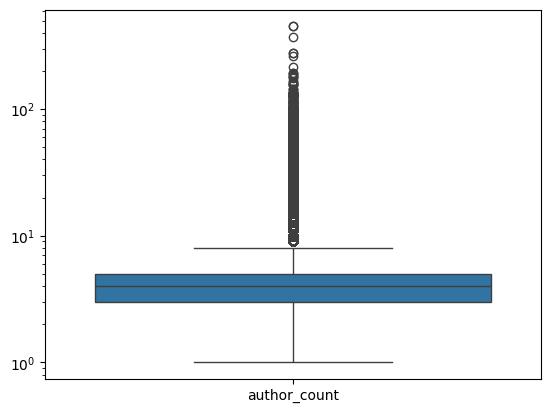

In [15]:
sns.boxplot(data=df[['author_count']])
plt.yscale('log')
plt.show()

In [16]:
len(df[df['author_count'] > 20])

6748

In [17]:
print(df[df['author_count'] > 20].shape[0] / df.shape[0] * 100)

0.17260506002936946


In [18]:
df = df[df['author_count'] <= 20]

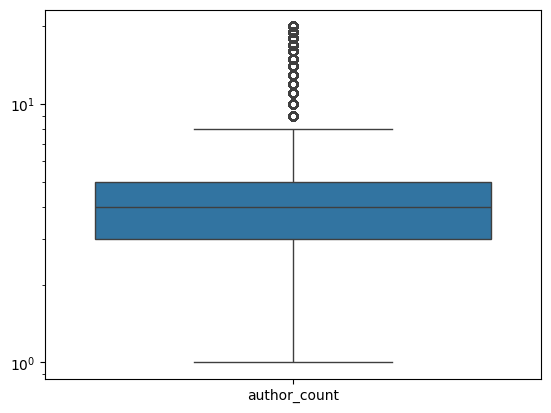

In [19]:
sns.boxplot(data=df[['author_count']])
plt.yscale('log')
plt.show()

In [20]:
df['first_author'] = (df['authors'].str.split(',').str[0])
df.head()

,type,year,title,authors,source,author_count,title_length,first_author
0,incollection,2021,Blockchains and Distributed Ledgers Uncovered:...,"Eder J. Scheid, Bruno Bastos Rodrigues, Christ...",IFIP's Exciting First 60+ Years,6,93,Eder J. Scheid
1,incollection,2024,A Common Ground for Developing a Global Consci...,Don Gotterbarn,IFIP TC9 50th Anniversary Anthology,1,103,Don Gotterbarn
2,incollection,2021,An IFIP WG5.8 State-of-the-Art View on Methods...,"Georg Weichhart, Yves Ducq, Guy Doumeingts",IFIP's Exciting First 60+ Years,3,99,Georg Weichhart
3,incollection,2021,IFIP Code of Ethics.,David Kreps,IFIP's Exciting First 60+ Years,1,20,David Kreps
4,incollection,2024,Introduction - Legacies of the Formation of IF...,"Christopher Leslie, David Kreps",IFIP TC9 50th Anniversary Anthology,2,71,Christopher Leslie


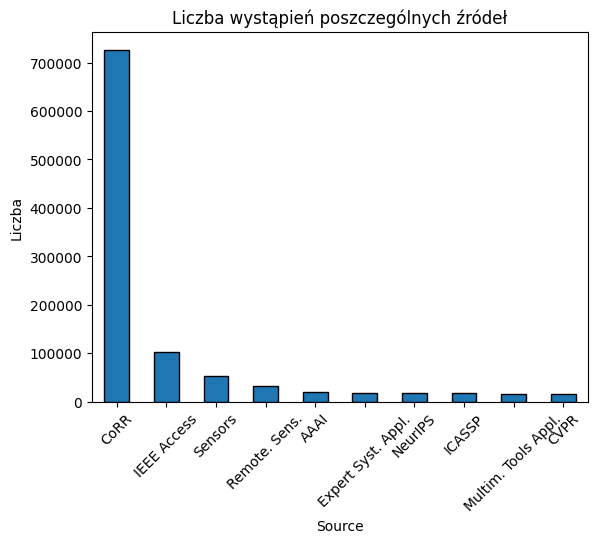

In [21]:
df['source'].value_counts().head(10).plot(kind='bar', edgecolor='black')
plt.title('Liczba wystąpień poszczególnych źródeł')
plt.ylabel('Liczba')
plt.xlabel('Source')
plt.xticks(rotation=45)
plt.show()

In [22]:
df['first_author'].value_counts().head(10)

first_author
                43786
Yang Liu          413
Yu Wang           346
Yu Zhang          329
Wei Wang          328
Hao Wang          319
Jan Pfeiffer      319
Yang Li           306
Wei Li            304
Yan Wang          300
Name: count, dtype: int64

In [23]:
df_ = df[df['authors'] == '']   
df_['title'].value_counts().head(10)

title
Front Matter, Table of Contents, Preface, Conference Organization.    337
Issue Information.                                                    170
Frontmatter.                                                          168
Editorial Board.                                                      153
Preface.                                                              132
Correction.                                                            82
Retraction.                                                            66
DuD Recht.                                                             63
Editorial.                                                             62
Issue Publication Information.                                         58
Name: count, dtype: int64

In [24]:
df_.shape

(43786, 8)

In [25]:
df = df[df['authors'].str.strip() != '']

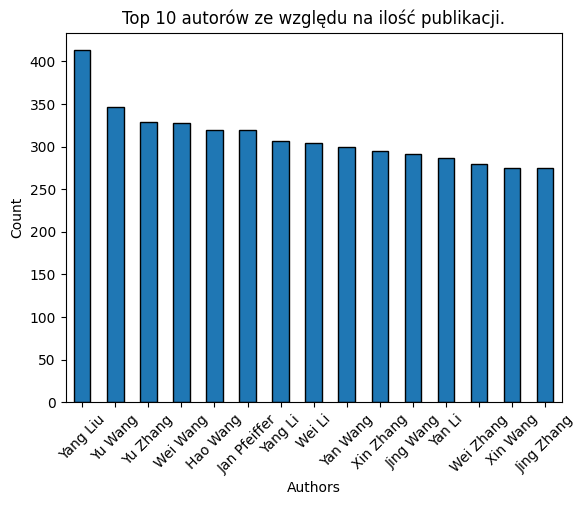

In [26]:
df['first_author'].value_counts().head(15).plot(kind='bar', edgecolor='black')
plt.title('Top 10 autorów ze względu na ilość publikacji.')
plt.ylabel('Count')
plt.xlabel('Authors')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x800 with 0 Axes>

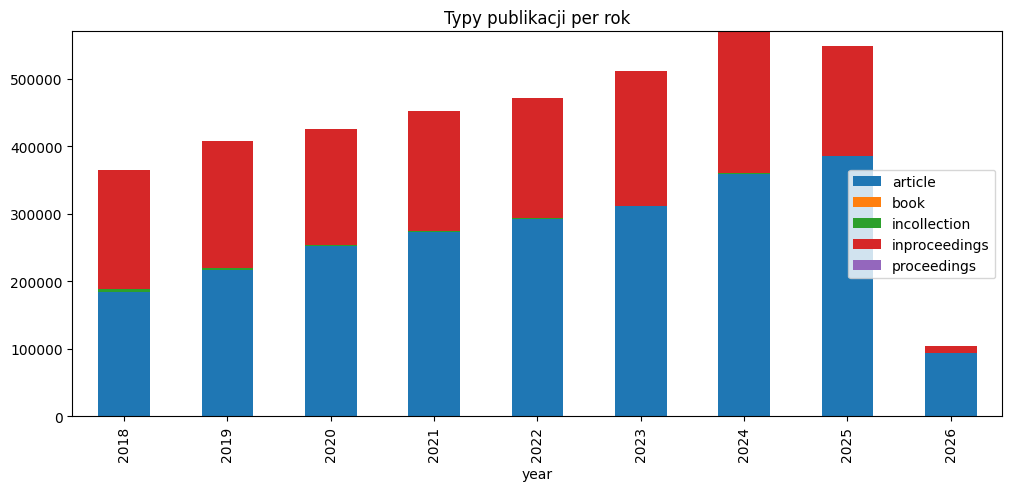

In [27]:
plt.figure(figsize=(12, 8))
df.groupby(['year', 'type']).size().unstack().plot(kind='bar', stacked=True, figsize=(12,5))
plt.title("Typy publikacji per rok")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Średnia liczba autorów per paper (trend)')

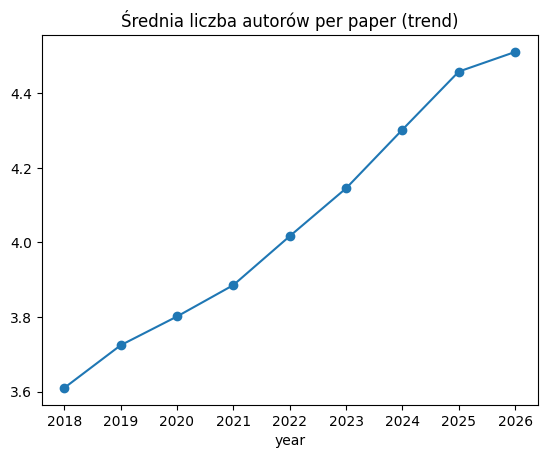

In [28]:
df.groupby('year')['author_count'].mean().plot(marker='o')
plt.title("Średnia liczba autorów per paper (trend)")

Text(0.5, 1.0, 'Aktywność top 10 źródeł per rok')

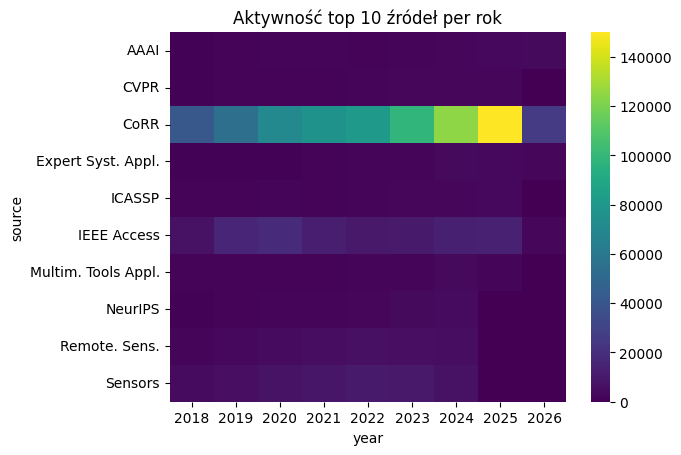

In [29]:
top10_sources = df['source'].value_counts().head(10).index
pivot = df[df['source'].isin(top10_sources)].groupby(['year','source']).size().unstack(fill_value=0)
sns.heatmap(pivot.T, cmap='viridis', fmt='d', annot=False)
plt.title("Aktywność top 10 źródeł per rok")

Text(0.5, 1.0, 'Długość tytułu per typ')

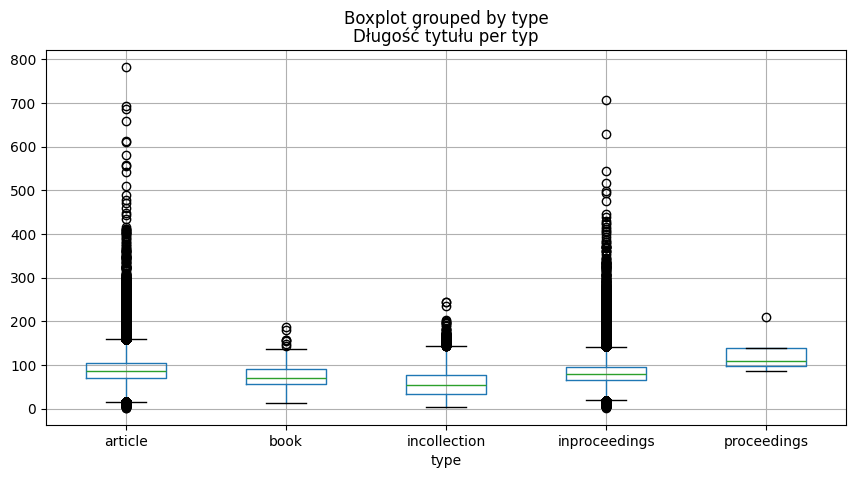

In [30]:
df.boxplot(column='title_length', by='type', figsize=(10,5))
plt.title("Długość tytułu per typ")

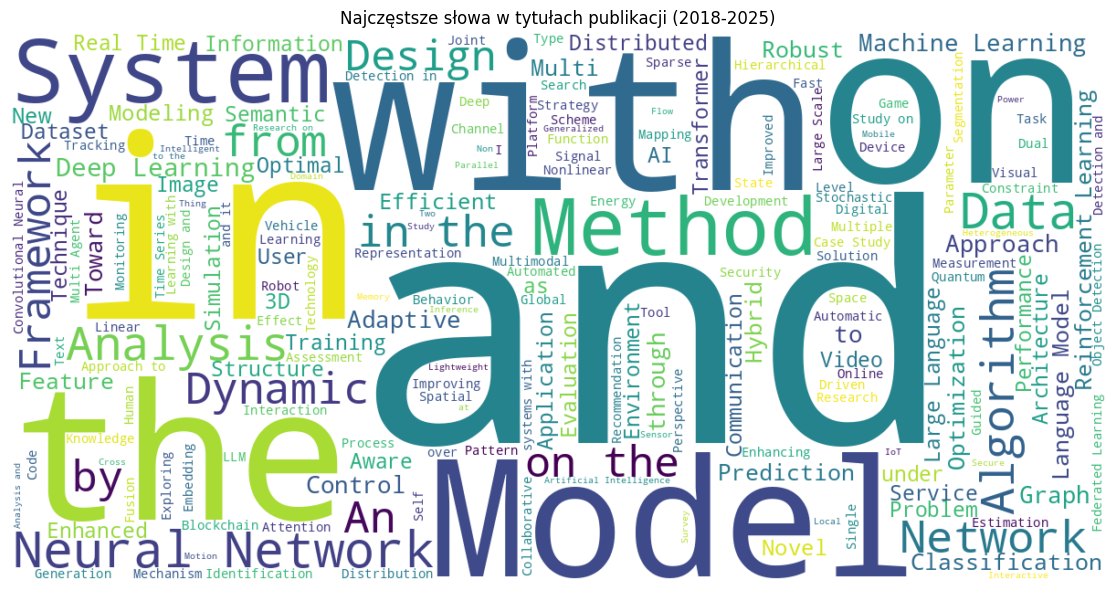

In [31]:
text = ' '.join(df['title'].dropna().sample(50_000, random_state=42))
wc = WordCloud(width=1200, height=600, background_color='white',
               stopwords={'using', 'based', 'via', 'for', 'of', 'a'}).generate(text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Najczęstsze słowa w tytułach publikacji (2018-2025)")
plt.tight_layout()
plt.show()

In [32]:
df.to_parquet('../data/processed/dblp_eda.parquet')